# Piano Music Transcription

The goal of this homework is implementing ``onsets and frames'', a state-of-the-art piano transcription model and furturemore improving the model with your ideas.

## Download the Dataset

We use a subset of the MAESTRO dataset that contains 170 performance pieces played by junior pianists. The audio files and their corresponding midi files are paired for each piece. We will convert the midi files into piano rolls and train our network to predict them from the audio in a supervised way. We randomly selected 100 / 20 / 50 (train / valid / test) performances from the original dataset for this homework.

In [1]:
# # Download the audio files
# !gdown 1pXUloztNR3NV_gZEeYAEHuzSTfGws_b-

In [2]:
# # uncompress the audio files
# # %%capture prevents the output log from displaying in this cell. If you want to see the log, remove %%capture below.
# %%capture

# !unzip gct731-maestro.zip

Once you unzip the file, you will see the following folders in the ``gct731-maestro'' folder.

```
2004  2006  2008  2009  2011  2013  2014  2015  2017  2018  data.json
```


## Check the Audio and MIDI Files

Install python packages to handle audio and MIDI

In [3]:
# # %%capture prevents the output log from displaying in this cell. If you want to see the log, remove %%capture below.
# # %%capture

# !sudo apt install -y fluidsynth
# !pip install --upgrade pyfluidsynth
# !pip install pretty_midi
# !pip install mir_eval
# !pip install libfmp


Let's load an example of the audio files.

In [4]:
import soundfile
import IPython.display as ipd

audio_file = 'gct731-maestro/2009/MIDI-Unprocessed_08_R1_2009_01-04_ORIG_MID--AUDIO_08_R1_2009_08_R1_2009_03_WAV.flac'
audio, sr = soundfile.read(audio_file)
audio_seg = audio[:10*sr]

ipd.Audio(audio_seg, rate=sr)


Can you hear the beautiful piano music? Then, let's load the paired MIDI file

(<Figure size 576x216 with 1 Axes>,
 <Axes: xlabel='Time (seconds)', ylabel='Pitch'>)

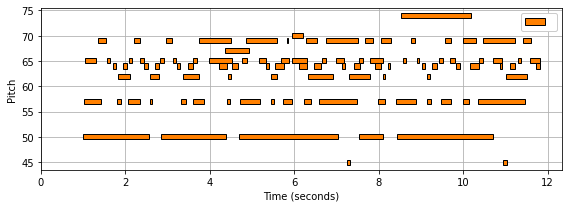

In [5]:
import libfmp.c1

midi_file = 'gct731-maestro/2009/MIDI-Unprocessed_08_R1_2009_01-04_ORIG_MID--AUDIO_08_R1_2009_08_R1_2009_03_WAV.midi'
score = libfmp.c1.midi_to_list(midi_file)
libfmp.c1.visualize_piano_roll(score[:100], figsize=(8, 3))

Now, we synthesize MIDI file back to audio using Fluidsynth

In [6]:
import fluidsynth
import pretty_midi

pm = pretty_midi.PrettyMIDI(midi_file)
synth_audio = pm.fluidsynth(fs=sr)

synth_audio_seg = synth_audio[:10*sr]

ipd.Audio(synth_audio_seg, rate=sr)

The piano timbre will be different. But, it should sound pretty good.

Now, we are going to build the onsets and frames model.

## Dataloader
This cell includes data loaders and mel-spectrogram setting. We are just going to use the functions.

In [ ]:
# Refactored: load constants and dataset utilities from modules
from pathlib import Path
import sys

# Support running this notebook from either `hw1/` or repository root.
if (Path.cwd() / "config.py").exists():
    sys.path.append(str(Path.cwd()))
elif (Path.cwd() / "hw1" / "config.py").exists():
    sys.path.append(str(Path.cwd() / "hw1"))

import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import (
    SAMPLE_RATE,
    MIN_MIDI,
    MAX_MIDI,
    HOP_SIZE,
    N_MELS,
    N_FFT,
    F_MIN,
    F_MAX,
    N_PIANO_KEYS,
    DEFAULT_DATASET_PATH,
    DEFAULT_LEARNING_RATE,
    DEFAULT_BATCH_SIZE,
    DEFAULT_SEQUENCE_LENGTH,
    DEFAULT_WEIGHT_DECAY,
    DEFAULT_CNN_UNIT,
    DEFAULT_FC_UNIT,
    DEFAULT_RNN_UNIT,
    DEFAULT_NUM_EPOCHS,
    DEFAULT_STEPS_PER_EPOCH,
)
from data_zoo import MAESTRO_small, allocate_batch

if (Path.cwd() / DEFAULT_DATASET_PATH).exists():
    NOTEBOOK_DATASET_PATH = DEFAULT_DATASET_PATH
elif (Path.cwd() / "hw1" / DEFAULT_DATASET_PATH).exists():
    NOTEBOOK_DATASET_PATH = str(Path("hw1") / DEFAULT_DATASET_PATH)
else:
    NOTEBOOK_DATASET_PATH = DEFAULT_DATASET_PATH

print(f"Dataset path used in notebook: {NOTEBOOK_DATASET_PATH}")


## Build the Model

This cell includes neural network modules to build the onsets and frames model along with the mel-spectrogram. This is the main part that you are going to work on for this homework.

In [ ]:
# Refactored: import model definitions from model_zoo.py
from model_zoo import (
    LogMelSpectrogram,
    ConvStack,
    BiLSTM,
    BasicOnsetsAndFrames,
    OnsetsAndFrames,
)


## Evaluation Functions

This cell includes evaluation functions which compute frame-level and note-level accuracy metrics. ``extract_notes'' is used to infer MIDI notes from the onset and frame predictions.

In [ ]:
# Refactored: import evaluation utilities from evaluate.py
from evaluate import (
    evaluate_batch,
    framewise_eval,
    extract_notes,
    print_f1_metrics,
    save_midi,
)


## Train and Validate the Model

This cell in the main part to train and validate the model using data loaders and an optimizer.

In [ ]:
# Refactored: import trainer from trainer.py
from trainer import Runner, cycle


Let's start training the model!

In [ ]:
# Training loop (notebook version) using refactored modules
learning_rate = DEFAULT_LEARNING_RATE
batch_size = DEFAULT_BATCH_SIZE
steps_per_epoch = DEFAULT_STEPS_PER_EPOCH
sequence_length = DEFAULT_SEQUENCE_LENGTH
weight_decay = DEFAULT_WEIGHT_DECAY
cnn_unit = DEFAULT_CNN_UNIT
fc_unit = DEFAULT_FC_UNIT
rnn_unit = DEFAULT_RNN_UNIT
NUM_EPOCHS = DEFAULT_NUM_EPOCHS

train_dataset = MAESTRO_small(
    path=NOTEBOOK_DATASET_PATH,
    groups=['train'],
    sequence_length=sequence_length,
    hop_size=HOP_SIZE,
    random_sample=True,
)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

valid_dataset = MAESTRO_small(
    path=NOTEBOOK_DATASET_PATH,
    groups=['validation'],
    sequence_length=sequence_length,
    hop_size=HOP_SIZE,
    random_sample=False,
)
valid_loader = DataLoader(valid_dataset, batch_size, shuffle=False)

model = BasicOnsetsAndFrames(cnn_unit=cnn_unit, fc_unit=fc_unit)
# model = OnsetsAndFrames(cnn_unit=cnn_unit, fc_unit=fc_unit, rnn_unit=rnn_unit)

runner = Runner(
    model=model,
    lr=learning_rate,
    weight_decay=weight_decay,
    steps_per_epoch=steps_per_epoch,
)

for epoch in range(NUM_EPOCHS):
    print(f"[Epoch {epoch + 1}/{NUM_EPOCHS}]")
    train_loss = runner.train_epoch(train_loader)
    valid_loss, metrics = runner.validate(valid_loader)
    print(f"train_loss: {train_loss:.6f}")
    print(f"valid_loss: {valid_loss:.6f}")
    print_f1_metrics(metrics)


## Transcribe a piece of piano recording

Let's transcribe a piano music piece using the trained model.

In [ ]:
import math
import torch.nn.functional as F
from mir_eval.util import midi_to_hz

# We use the same example piano piece from earlier cells.
audio_file = str(Path(NOTEBOOK_DATASET_PATH) / '2009' / 'MIDI-Unprocessed_08_R1_2009_01-04_ORIG_MID--AUDIO_08_R1_2009_08_R1_2009_03_WAV.flac')
audio, sr = soundfile.read(audio_file)
if audio.ndim == 2:
    audio = audio.mean(axis=1)
audio_seg = audio[:10 * sr]

device = runner.device if 'runner' in globals() else (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
model = model.to(device)
model.eval()

with torch.no_grad():
    t_audio = torch.tensor(audio_seg, dtype=torch.float32, device=device)
    pad_len = math.ceil(len(t_audio) / HOP_SIZE) * HOP_SIZE - len(t_audio)
    t_audio = torch.unsqueeze(F.pad(t_audio, (0, pad_len)), 0)

    frame_pred, onset_pred = model(t_audio)
    p_est, i_est = extract_notes(onset_pred[0], frame_pred[0])

scaling = HOP_SIZE / SAMPLE_RATE
i_est = (i_est * scaling).reshape(-1, 2)
p_est = np.array([midi_to_hz(MIN_MIDI + pitch) for pitch in p_est])

midi_output_filename = 'output.midi'
save_midi(midi_output_filename, p_est, i_est, [64] * len(p_est))

midi_file = pretty_midi.PrettyMIDI(str(midi_output_filename))
synth_audio = midi_file.fluidsynth(fs=SAMPLE_RATE)

midi_score = libfmp.c1.midi_to_list(midi_output_filename)
libfmp.c1.visualize_piano_roll(midi_score, figsize=(8, 3))

ipd.Audio(synth_audio, rate=SAMPLE_RATE)


# Credit
This homework was implemented and improved by Taegyun Kwon and Juhan Nam from the KAIST Music and Audio Computing Lab.
